# Explore here

### Paso 1: Planteamiento del problema y recopilación de datos
Una empresa ha recolectado la información del alquiler de viviendas en Nueva York a través de la aplicación Airbnb durante el año 2019. Este conjunto de datos se utilizó para entrenar modelos de Machine Learning durante ese año, en una competición en abierto.

Ahora lo utilizaremos para llevar a cabo un estudio acerca de las variables que componen el dataset a fin de comprenderlo y obtener conclusiones sobre él.

In [13]:
import pandas as pd
total_data = pd.read_csv("/workspaces/machine-learning-python-template.-JohnnyReyesBorbor/data/raw/internal-link.csv")
total_data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


### Paso 2: Exploración y limpieza de datos
Hay que conocer las dimensiones y tipologías de datos del objeto con el que estamos trabajando es vital. Para ello necesitamos el atributo shape para obtener las dimensiones del objeto y la función info() para conocer la tipología y la cantidad de valores no nulos:

In [14]:
#Conocer las dimensiones
total_data.shape

(48895, 16)

In [15]:
# Obtener información sobre tipos de datos y valores no nulos
total_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

Una vez hemos obtenido esta información, es importante que seamos capaces de extraer conclusiones, como las siguientes:

Existen un total de 48895 filas (en este caso, apartamentos/alojamientos) y 16 columnas.

En todalas variable sno hay una gran cantidad de valores nulos, siendo la mayoria casi ninguno o ninguno. Las dos variables con mayores NA son las dos relacionadas a las reseñas. 

Los datos cuentan con 10 características numéricas y 6 características categóricas.

Eliminar duplicados:

Un punto muy importante a tener en cuenta en este paso es eliminar aquellas instancias que pudieran estar duplicadas en el conjunto de datos. Esto es crucial, ya que, de dejarlo, el mismo punto tendría varias representaciones, lo cual es matemáticamente incoherente e incorrecto. Para ello, hemos de ser inteligentes buscando duplicados y conocer previamente si los hay y dónde, antes de eliminarlos. Además, tenemos que tener en cuenta que una instancia puede estar repetida independientemente del identificador que pueda tener, así que en este caso nos interesa eliminar del análisis la variable id, ya que podría estar mal generada.

In [16]:
total_data.drop("id", axis = 1).duplicated().sum()

#No hay duplicados

np.int64(0)

Eliminar información irrelevante:

Cuando queremos preparar los datos para entrenar un modelo predictivo, debemos responder a la siguiente pregunta: ¿son todas las características imprescindibles para realizar una predicción? Normalmente, esa pregunta es un rotundo no. Tenemos que tratar de ser lo más objetivos posible y llevar a cabo este proceso previo antes de la fase de selección de características. Por lo tanto, aquí lo que trataremos de hacer es una eliminación controlada de aquellas variables que podemos estar seguros de que el algoritmo no va a utilizar en el proceso predictivo, estas son id,host_id, name, host_name, latitude, longitude, last review y reviews per month

In [17]:
total_data.drop(["id", "name", "host_name","host_id", "latitude","longitude","last_review","reviews_per_month"], axis = 1, inplace = True)
total_data.head()

,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,Private room,149,1,9,6,365
1,Manhattan,Midtown,Entire home/apt,225,1,45,2,355
2,Manhattan,Harlem,Private room,150,3,0,1,365
3,Brooklyn,Clinton Hill,Entire home/apt,89,1,270,1,194
4,Manhattan,East Harlem,Entire home/apt,80,10,9,1,0


### Paso 3: Análisis de variables univariante
Una variable univariante es un término estadístico que se emplea para referenciar un conjunto de observaciones de un atributo. Esto es, el análisis columna a columna del DataFrame. Para ello, debemos distinguir si una variable es categórica o numérica, ya que el cuerpo del análisis y las conclusiones que se pueden obtener serán distintas.

**Análisis sobre variables categóricas**:

Una variable categórica es un tipo de variable que puede tomar uno de un número limitado de categorías o grupos. Estos grupos son a menudo nominales (por ejemplo, el color de un coche: rojo, azul, negro, etc, pero ninguno de estos colores es inherentemente "mayor" o "mejor" que los demás) pero pueden también representarse mediante números finitos.

Para representar este tipo de variables utilizaremos histogramas. Antes de comenzar a graficar, debemos identificar cuáles son categóricas, y se puede comprobar fácilmente analizando el rango de valores. En este caso, las variables categóricas son Neighbourhood, Neighbourhood group y room_type:

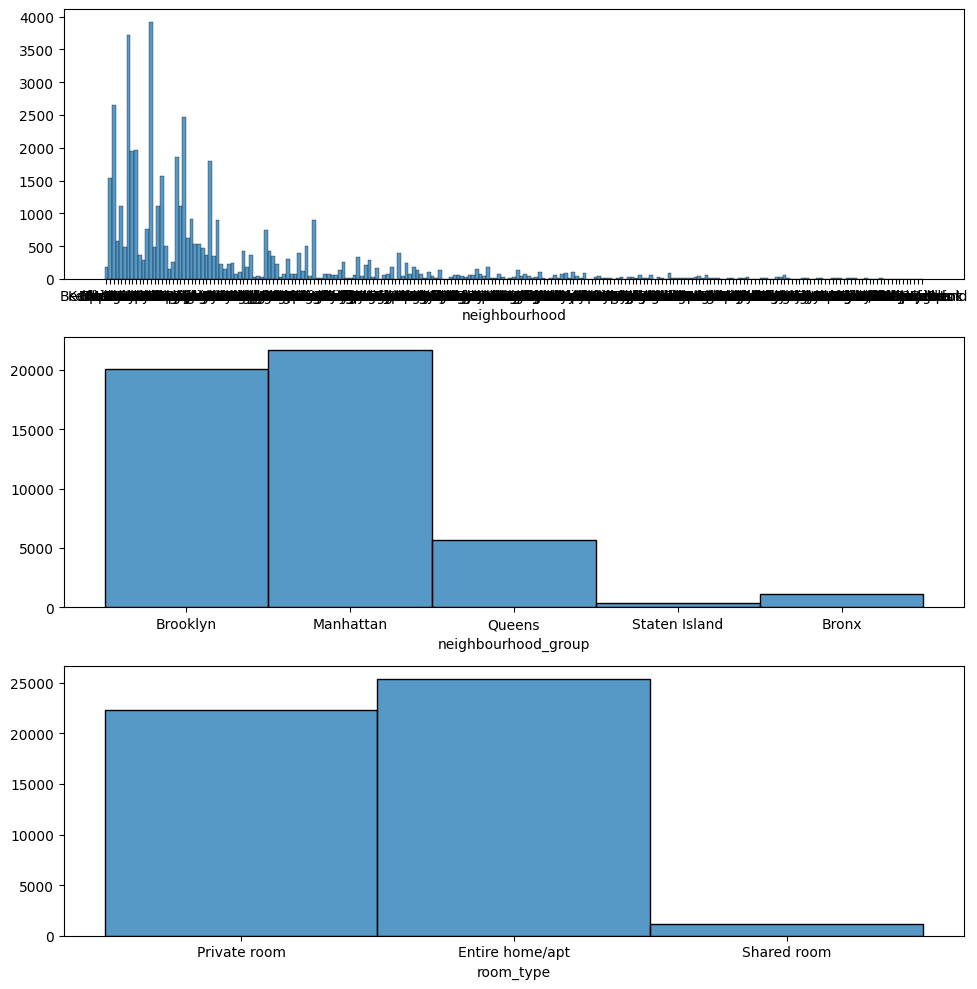

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axis = plt.subplots(3, 1, figsize = (10, 10))

# Crear un histograma múltiple
sns.histplot(ax = axis[0], data = total_data, x = "neighbourhood").set(ylabel = None)
sns.histplot(ax = axis[1], data = total_data, x = "neighbourhood_group").set(ylabel = None)
sns.histplot(ax = axis[2], data = total_data, x = "room_type").set(ylabel = None)
# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

Un histograma es una representación gráfica de la distribución de un conjunto de datos. Se utiliza además para comprender la frecuencia de los datos. Al observar un histograma, podemos entender si los datos están sesgados hacia un extremo, si son simétricos, si tienen muchos valores atípicos, etcétera. Con la representación de cada variable podemos determinar que:

- **Neighbourhood**: Muchos barrios para poder determinar algo
- **Neighbourhood_group**: Brooklyn y Manhattan siendo los barrios con mas alojamientos.
- **Room_type**: Igualdad entre una habitación sola / Piso entero. Poca demanda de habitaciones compartidas.

**Análisis sobre variables numéricas**:

Una variable numérica es un tipo de variable que puede tomar valores numéricos (enteros, fracciones, decimales, negativos, etc.) en un rango infinito. Una variable categórica numérica puede ser también una variable numérica (por ejemplo, para los sucesivos análisis, podemos tomar la clase Survived como numérica también para estudiar relaciones). Normalmente se representan utilizando un histograma y diagramas de caja, expuestos juntos. Antes de comenzar a graficar, debemos también identificar cuáles son las numéricas, que son  price, minimum_nights, number_of_reviews, calculated_host_listings_count	availability_365 y Host_id. Sin embargo, esta última carece de sentido, así que graficaremos las demás:

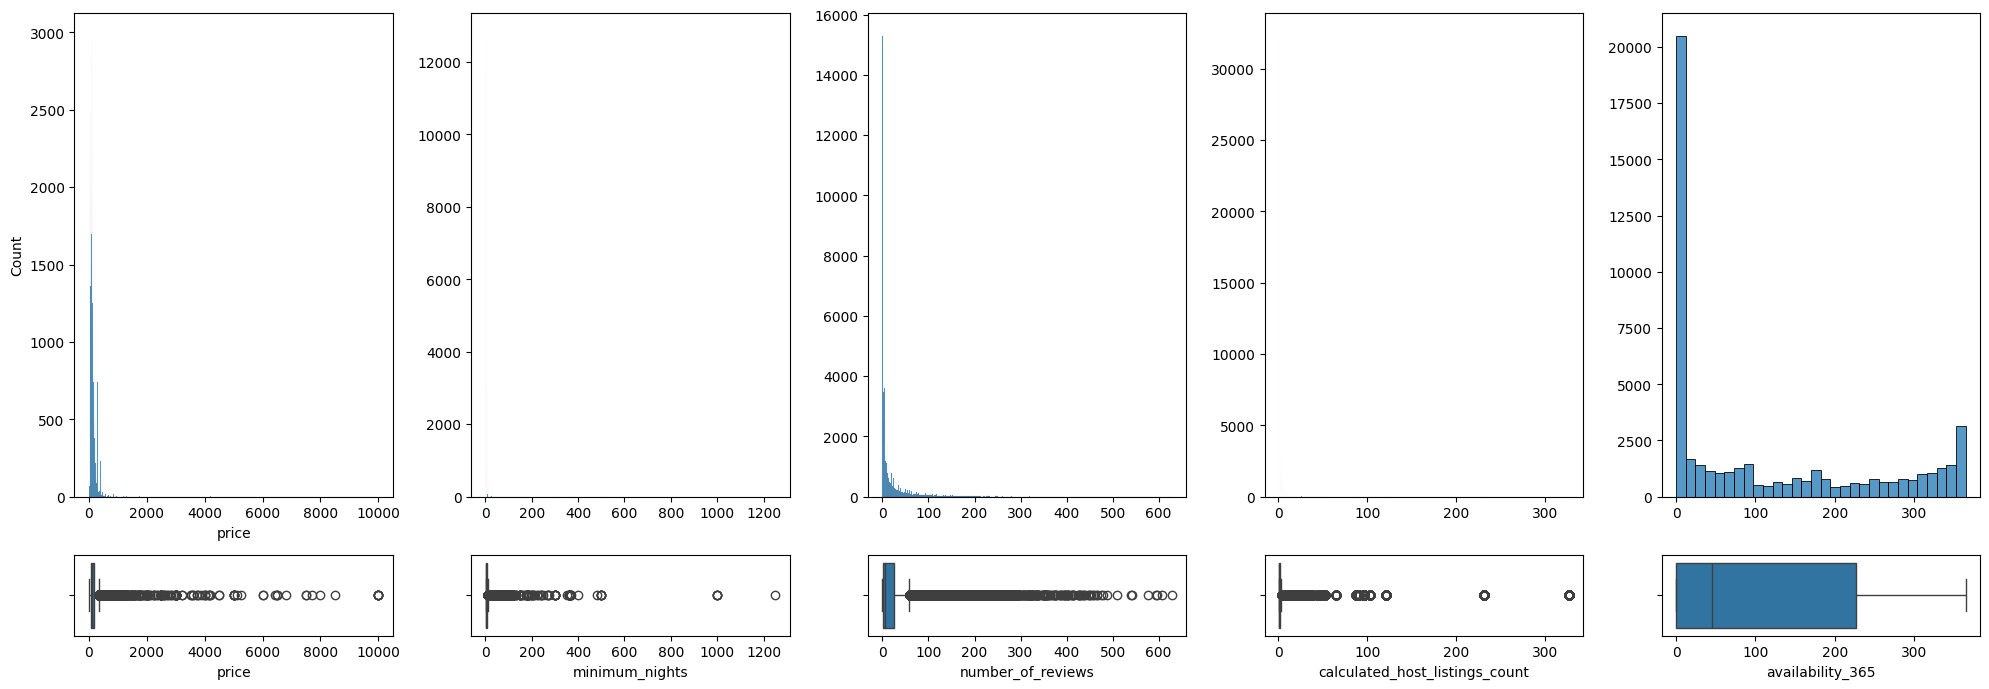

In [19]:
fig, axis = plt.subplots(2, 5, figsize = (20, 7), gridspec_kw={'height_ratios': [6, 1]})

# Crear una figura múltiple con histogramas y diagramas de caja
sns.histplot(ax = axis[0, 0], data = total_data, x = "price")
sns.boxplot(ax = axis[1, 0], data = total_data, x = "price")
sns.histplot(ax = axis[0, 1], data = total_data, x = "minimum_nights").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 1], data = total_data, x = "minimum_nights")
sns.histplot(ax = axis[0, 2], data = total_data, x = "number_of_reviews").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 2], data = total_data, x = "number_of_reviews")
sns.histplot(ax = axis[0, 3], data = total_data, x = "calculated_host_listings_count").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 3], data = total_data, x = "calculated_host_listings_count")
sns.histplot(ax = axis[0, 4], data = total_data, x = "availability_365").set(xlabel = None, ylabel = None)
sns.boxplot(ax = axis[1, 4], data = total_data, x = "availability_365")


# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

Valores atipicos muy grandes que no deja analizar bien los datos.

## Paso 4: Análisis de variables multivariante

Tras analizar las características una a una, es momento de analizarlas en relación con la predictora y con ellas mismas, para sacar conclusiones más claras acerca de sus relaciones y poder tomar decisiones sobre su procesamiento.

Así, si quisiéramos eliminar una variable debido a una alta cantidad de valores nulos o ciertos outliers, es necesario antes aplicar este proceso para asegurar que la eliminación de ciertos valores no son críticos

**Análisis numérico-numérico:**

Cuando las dos variables que se comparan tienen datos numéricos, se dice que el análisis es numérico-numérico. Para comparar dos columnas numéricas se utilizan diagramas de dispersión y análisis de correlaciones.

Price vs (minimum nights, number of reviews, host listing count and availability)


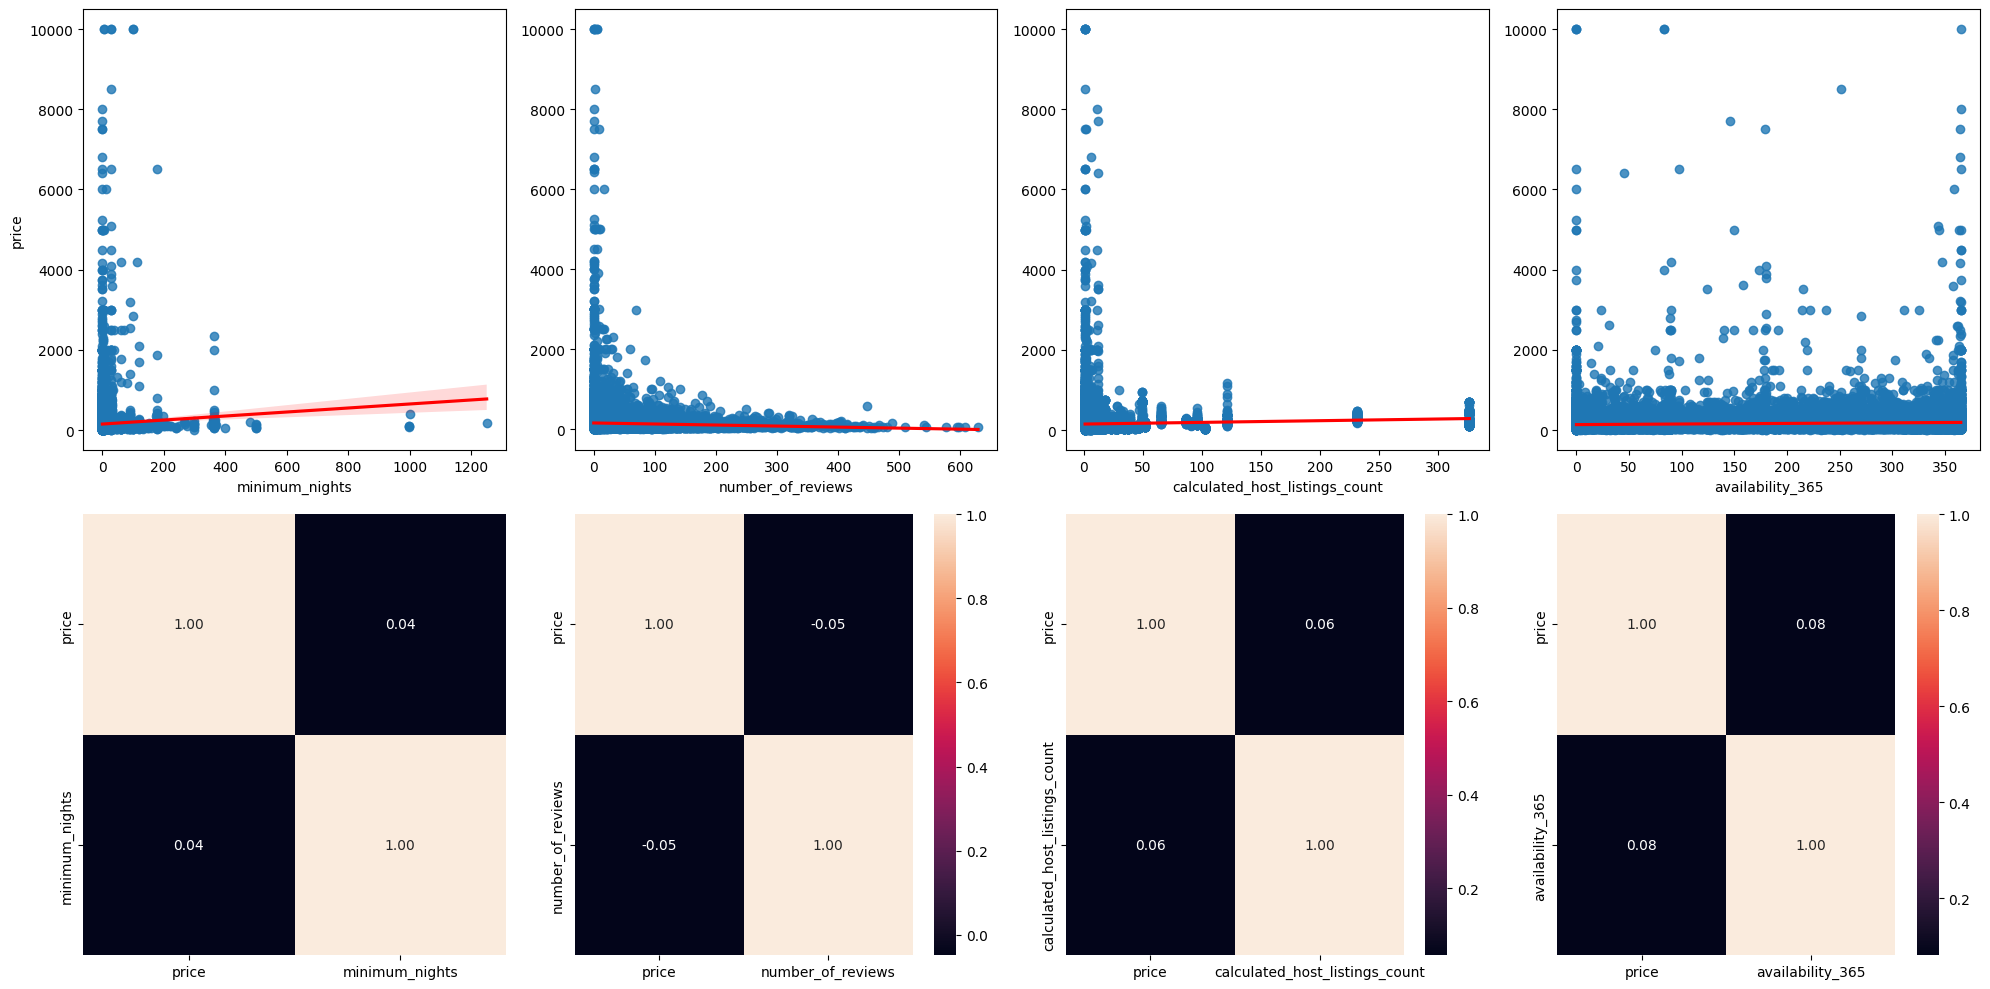

In [8]:
fig, axis = plt.subplots(2, 4, figsize = (20, 10))

# Crear un diagrama de dispersión múltiple
sns.regplot(ax = axis[0, 0], data = total_data, x = "minimum_nights", y = "price",line_kws={"color": "red"})
sns.heatmap(total_data[["price", "minimum_nights"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 0], cbar = False)
sns.regplot(ax = axis[0, 1], data = total_data, x = "number_of_reviews", y = "price",line_kws={"color": "red"}).set(ylabel=None)
sns.heatmap(total_data[["price", "number_of_reviews"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 1])
sns.regplot(ax = axis[0, 2], data = total_data, x = "calculated_host_listings_count", y = "price",line_kws={"color": "red"}).set(ylabel=None)
sns.heatmap(total_data[["price", "calculated_host_listings_count"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 2])
sns.regplot(ax = axis[0, 3], data = total_data, x = "availability_365", y = "price",line_kws={"color": "red"}).set(ylabel=None)
sns.heatmap(total_data[["price", "availability_365"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 3])

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

No existe mucha relación entre el precio y el resto de variables. La correlación es muy cercana a 0 en las 4 comparaciones.

**Análisis categórico-categórico**

Cuando las dos variables que se comparan tienen datos categóricos, se dice que el análisis es categórico-categórico. Para comparar dos columnas categóricas se utilizan histogramas y combinaciones.


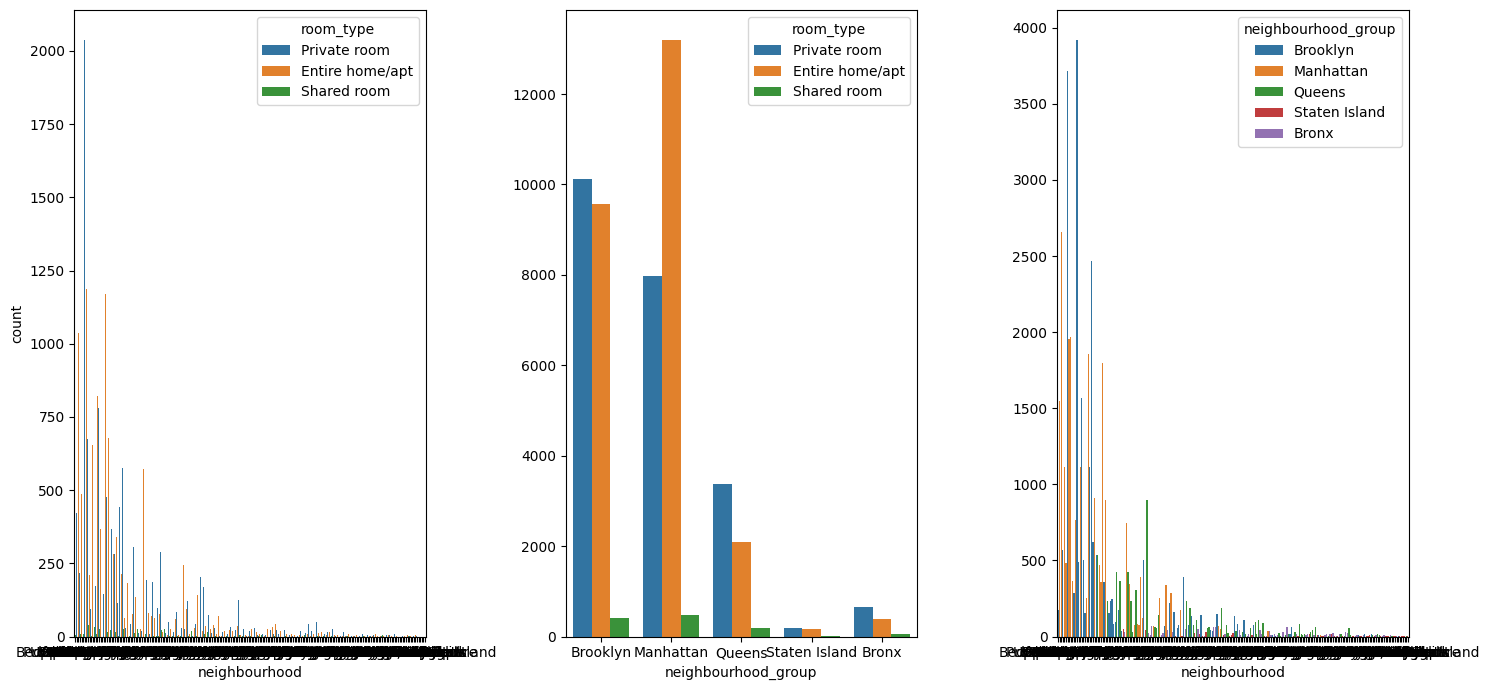

In [25]:
fig, axis = plt.subplots(1, 3, figsize = (15, 7))

sns.countplot(ax = axis[0], data = total_data, x = "neighbourhood", hue = "room_type")
sns.countplot(ax = axis[1], data = total_data, x = "neighbourhood_group", hue = "room_type").set(ylabel = None)
sns.countplot(ax = axis[2], data = total_data, x = "neighbourhood", hue = "neighbourhood_group").set(ylabel = None)

plt.tight_layout()
plt.show()

**Análisis de correlaciones**:


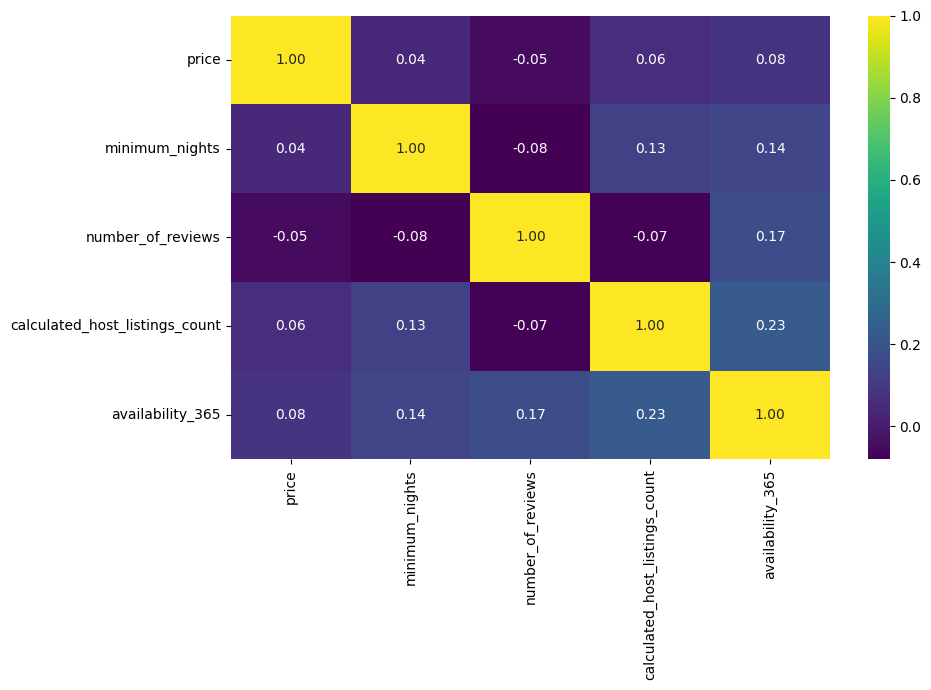

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

cols_num = ["price","minimum_nights", "number_of_reviews", "calculated_host_listings_count","availability_365"]  # todas numéricas
cols_cat=["neighbourhood_group","neighbourhood","room_type"]
fig, ax = plt.subplots(figsize=(10,7))
sns.heatmap(total_data[cols_num].corr(method="pearson"), annot=True, fmt=".2f", cmap="viridis", ax=ax)
plt.tight_layout()
plt.show()

Vamos a pasar las variables categóricas a variables númericas

In [37]:
total_data["room_type_n"] = pd.factorize(total_data.room_type)[0]
total_data["neighbourhood_group_n"] = pd.factorize(total_data.neighbourhood_group)[0]
total_data["neighbourhood_n"] = pd.factorize(total_data.neighbourhood)[0]

import json

room_type_transformation_rules = {row["room_type"]: row["room_type_n"] for index, row in total_data[["room_type_n", "room_type"]].drop_duplicates().iterrows()}
with open("./room_type_transformation_rules.json", "w") as f:
  json.dump(room_type_transformation_rules, f)

neighbourhood_transformation_rules = {row["neighbourhood"]: row["neighbourhood_n"] for index, row in total_data[["neighbourhood_n", "neighbourhood"]].drop_duplicates().iterrows()}
with open("./neighbourhood_transformation_rules.json", "w") as f:
  json.dump(neighbourhood_transformation_rules, f)

neighbourhood_group_transformation_rules = {row["neighbourhood_group"]: row["neighbourhood_group_n"] for index, row in total_data[["neighbourhood_group_n", "neighbourhood_group"]].drop_duplicates().iterrows()}
with open("./neighbourhood_group_transformation_rules.json", "w") as f:
  json.dump(neighbourhood_group_transformation_rules, f)


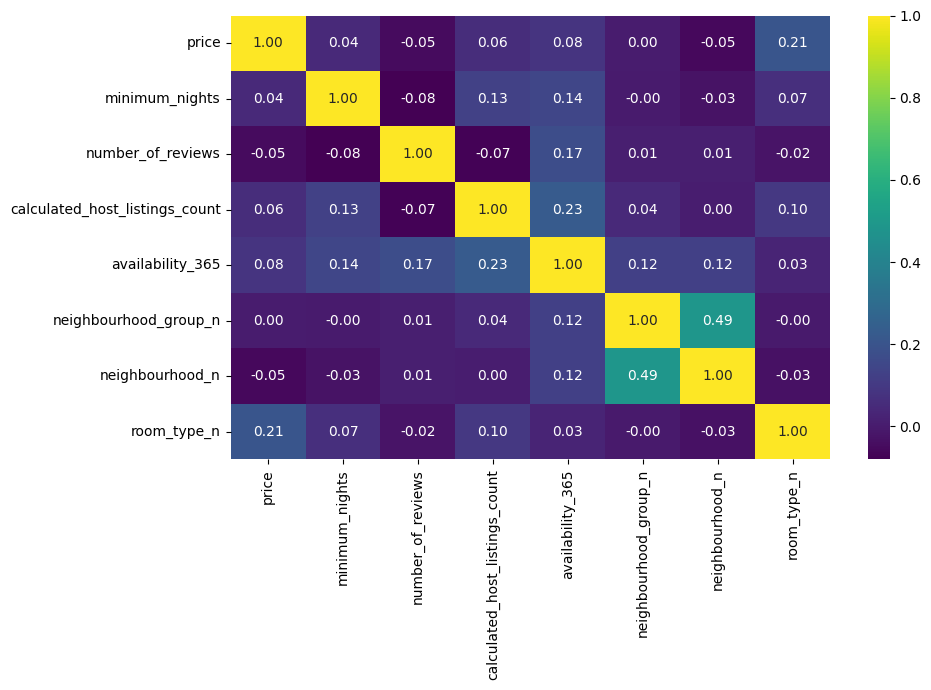

In [39]:
cols_num = ["price","minimum_nights", "number_of_reviews", "calculated_host_listings_count","availability_365","neighbourhood_group_n","neighbourhood_n","room_type_n"]  # todas numéricas
fig, ax = plt.subplots(figsize=(10,7))
sns.heatmap(total_data[cols_num].corr(method="pearson"), annot=True, fmt=".2f", cmap="viridis", ax=ax)
plt.tight_layout()
plt.show()

<Axes: >

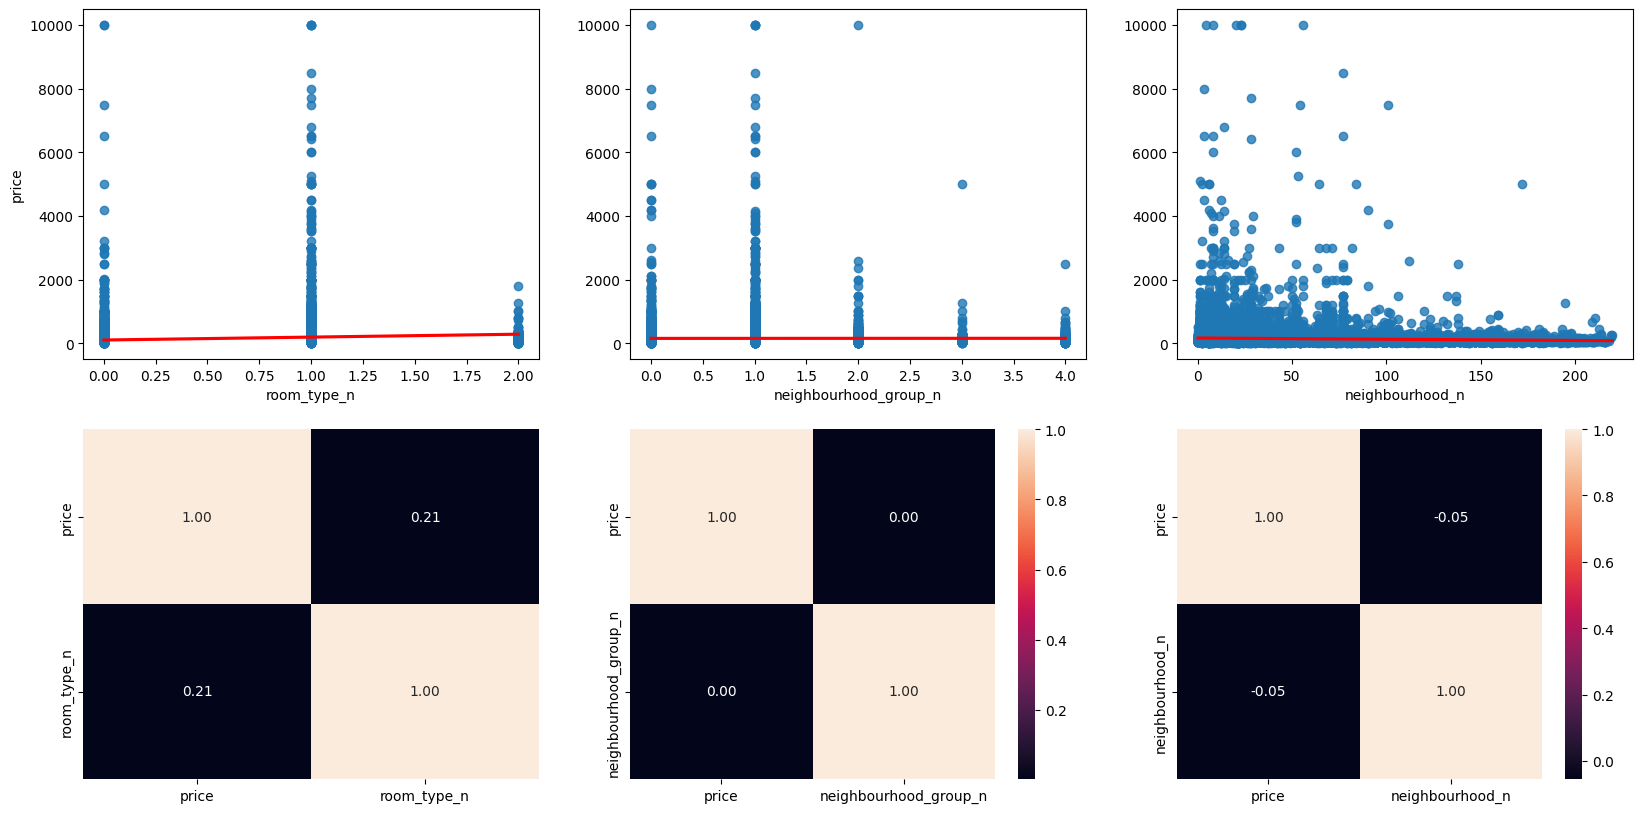

In [40]:

fig, axis = plt.subplots(2, 3, figsize = (20, 10))

# Crear un diagrama de dispersión múltiple
sns.regplot(ax = axis[0, 0], data = total_data, x = "room_type_n", y = "price",line_kws={"color": "red"})
sns.heatmap(total_data[["price", "room_type_n"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 0], cbar = False)
sns.regplot(ax = axis[0, 1], data = total_data, x = "neighbourhood_group_n", y = "price",line_kws={"color": "red"}).set(ylabel=None)
sns.heatmap(total_data[["price", "neighbourhood_group_n"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 1])
sns.regplot(ax = axis[0, 2], data = total_data, x = "neighbourhood_n", y = "price",line_kws={"color": "red"}).set(ylabel=None)
sns.heatmap(total_data[["price", "neighbourhood_n"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 2])



## Paso 5: Ingeniería de características

La ingeniería de características (*feature engineering*) es un proceso que implica la creación de nuevas características (o variables) a partir de las existentes para mejorar el rendimiento del modelo. Esto puede implicar una variedad de técnicas como la normalización, la transformación de los datos, etcétera. El objetivo es mejorar la precisión del modelo y/o reducir la complejidad del mismo, facilitando así su interpretación.

En los pasos previos hemos empezado a trabajar con los datos eliminando duplicados, contabilizando los valores nulos e, incluso, para calcular correlaciones. Si bien esto podríamos haberlo hecho en este paso, ya que forma parte de la ingeniería de características, normalmente suele hacerse antes de analizar las variables, separando este proceso en uno previo y este que vamos a ver a continuación.

**Análisis de outliers**

Un valor atípico (*outlier*) es un punto de datos que se desvía significativamente de los demás. Es un valor que es notablemente diferente de lo que sería de esperar dada la tendencia general de los datos. Estos outliers pueden ser causados por errores en la recolección de datos, variaciones naturales en los datos, o pueden ser indicativos de algo significativo, como una anomalía o evento extraordinario.

El análisis descriptivo es una poderosa herramienta para caracterizar el conjunto de datos: la media, desviación y los cuartiles nos brindan una poderosa información sobre cada variable. La función `describe()` de un DataFrame nos ayuda a calcular en unos tiempos muy reducidos todos estos valores.

In [42]:
FINAL_COLS = ["price","minimum_nights", "number_of_reviews", "calculated_host_listings_count","availability_365","neighbourhood_group_n","neighbourhood_n","room_type_n"] 
total_data = total_data[FINAL_COLS]
total_data.describe()

,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365,neighbourhood_group_n,neighbourhood_n,room_type_n
count,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,152.720687,7.029962,23.274466,7.143982,112.781327,0.786911,29.888782,0.567113
std,240.154170,20.510550,44.550582,32.952519,131.622289,0.844386,34.676634,0.541249
min,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,69.000000,1.000000,1.000000,1.000000,0.000000,0.000000,7.500000,0.000000
50%,106.000000,3.000000,5.000000,1.000000,45.000000,1.000000,19.000000,1.000000
75%,175.000000,5.000000,24.000000,2.000000,227.000000,1.000000,37.000000,1.000000
max,10000.000000,1250.000000,629.000000,327.000000,365.000000,4.000000,220.000000,2.000000


##### Cosas extrañas
1. Precio minimo es 0. Poco realista ya que no puedo haber alojamientos gratis.
2. El máximo mínimo de noches es 1250, mas de 3 años. 
3. El máximo de inquilinos es 327, bastante grande para un piso.

Todo esto unido a las gráficas del paso 3 nos indica la existencia de varios datos atípicos. Dibujar los diagramas de cajas de las variables también nos da una información muy poderosa sobre los valores atípicos que se salen de las regiones de confianza:

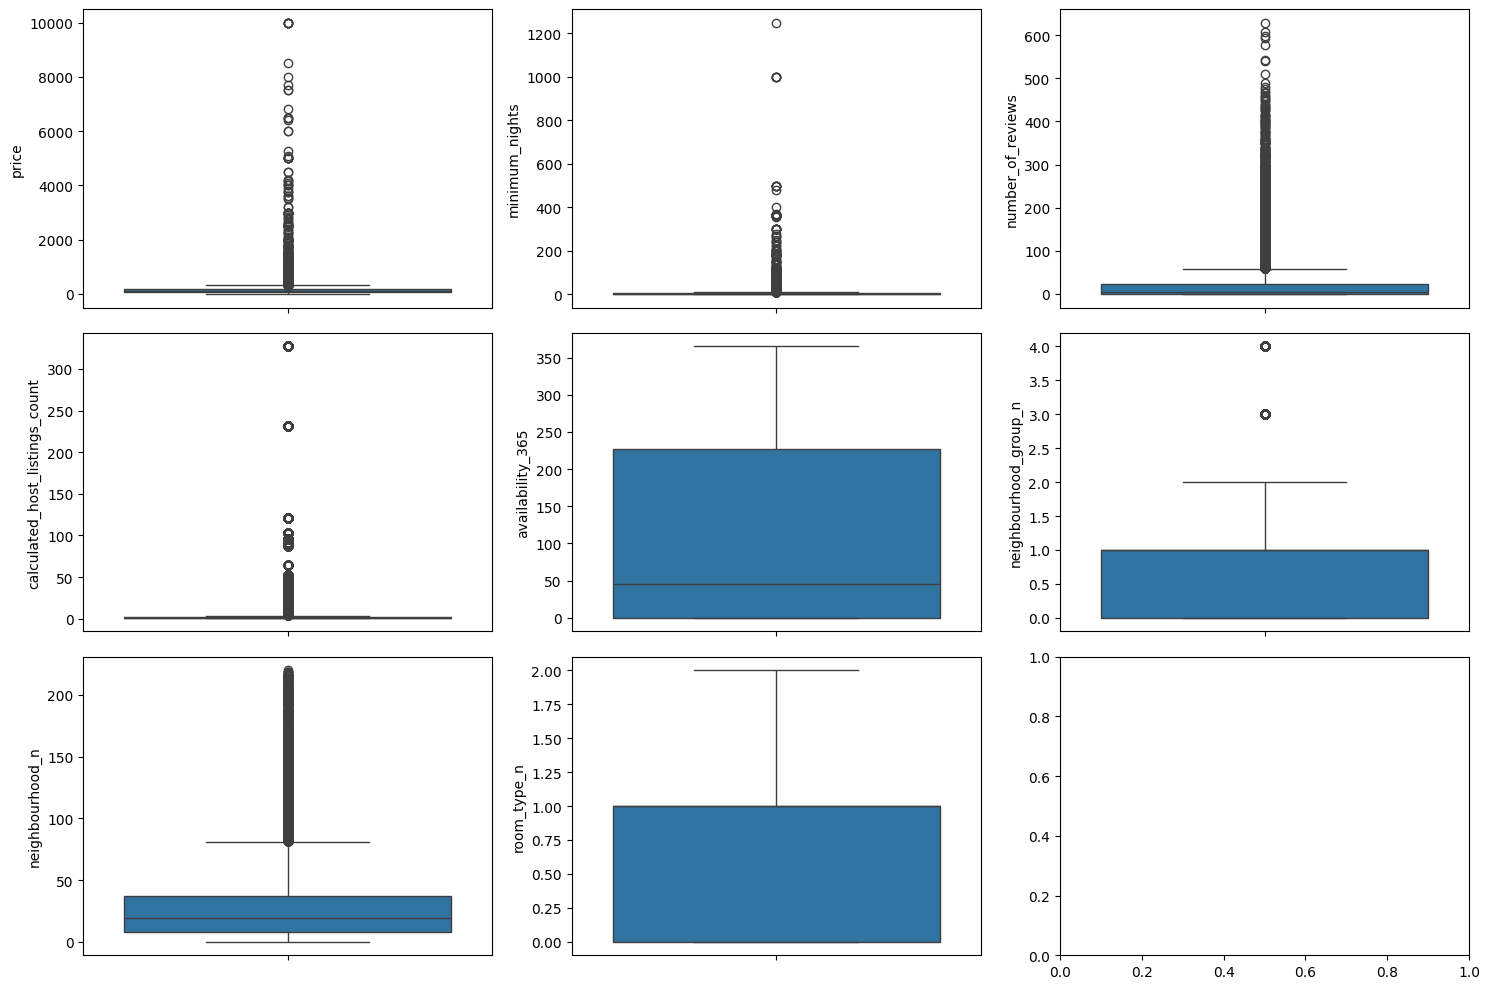

In [50]:
fig, axis = plt.subplots(3, 3, figsize = (15, 10))

sns.boxplot(ax = axis[0, 0], data = total_data, y = "price")
sns.boxplot(ax = axis[0, 1], data = total_data, y = "minimum_nights")
sns.boxplot(ax = axis[0, 2], data = total_data, y = "number_of_reviews")
sns.boxplot(ax = axis[1, 0], data = total_data, y = "calculated_host_listings_count")
sns.boxplot(ax = axis[1, 1], data = total_data, y = "availability_365")
sns.boxplot(ax = axis[1, 2], data = total_data, y = "neighbourhood_group_n")
sns.boxplot(ax = axis[2, 0], data = total_data, y = "neighbourhood_n")
sns.boxplot(ax = axis[2, 1], data = total_data, y = "room_type_n")

plt.tight_layout()

plt.show()

Podemos determinar fácilmente que las variables afectadas por outliers son `minimum_nights`, `number_of_reviews` y `calculated_host_listings_count`. En el caso de las noches mínimas  parece que la cantidad de 1250 noches no es muy común. Deberíamos establecer algunos límites superior e inferior para determinar si un punto de datos debe considerarse o no un valor atípico. También pueden ser errores de transcripcióncomo  en en caso de los precios nulos.

- Mantenerlos. En ciertos problemas de Machine Learning, un valor atípico puede decantar la predicción hacia una clase u otra (esto es muy común, por ejemplo, para detectar riesgos). Por lo tanto, podría ser una política que en ciertos casos tuviera sentido. Normalmente no se utiliza.

- Reemplazarlos. Si no queremos eliminar instancias completas por la presencia de outliers en una de sus características, podemos reemplazarlos tomándolos en cuenta como valores faltantes y reutilizando la política.

In [74]:
total_data = total_data[total_data["price"] > 0]
total_data.describe() #Elimino los precios nulos

,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365,neighbourhood_group_n,neighbourhood_n,room_type_n
count,48884.000000,48884.000000,48884.000000,48884.000000,48884.000000,48884.000000,48884.000000,48884.000000
mean,152.755053,7.029887,23.271991,7.144628,112.779498,0.786986,29.889534,0.567118
std,240.170260,20.512224,44.551331,32.956185,131.627271,0.844288,34.673859,0.541183
min,10.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,69.000000,1.000000,1.000000,1.000000,0.000000,0.000000,8.000000,0.000000
50%,106.000000,3.000000,5.000000,1.000000,45.000000,1.000000,19.000000,1.000000
75%,175.000000,5.000000,24.000000,2.000000,227.000000,1.000000,37.000000,1.000000
max,10000.000000,1250.000000,629.000000,327.000000,365.000000,4.000000,220.000000,2.000000


In [75]:
total_data_CON_outliers = total_data.copy()
total_data_SIN_outliers = total_data.copy() # Lo vamos a modificar. Para cada variable con outliers, reemplazamos sus valores outliers

outliers_cols = ["price", "minimum_nights", "calculated_host_listings_count", "number_of_reviews"]

def replace_outliers(column, df):
  col_stats = total_data[column].describe()
  col_iqr = col_stats["75%"] - col_stats["25%"]
  upper_limit = round(float(col_stats["75%"] + 1.5 * col_iqr), 2)
  lower_limit = round(float(col_stats["25%"] - 1.5 * col_iqr), 2)

  if lower_limit < 0: lower_limit = min(df[column])
  # Vamos a quitar los outliers superiores
  df[column] = df[column].apply(lambda x: x if (x <= upper_limit) else upper_limit)
  # Vamos a quitar los outliers inferiores
  df[column] = df[column].apply(lambda x: x if (x >= lower_limit) else lower_limit)
  return df.copy(), [lower_limit, upper_limit]

outliers_dict = {}
for column in outliers_cols:
  total_data_SIN_outliers, limits = replace_outliers(column, total_data_SIN_outliers)
  outliers_dict.update({column: limits})

outliers_dict # Este JSON me lo tengo que GUARDAR
with open("./outliers_dict.json", "w") as f:
  json.dump(outliers_dict, f)

**Análisis de valores faltantes**

Un *valor faltante* (*missing value*) es un espacio que no tiene valor asignado en la observación de una variable específica. Este tipo de valores son bastante comunes y pueden surgir por muchas razones. Por ejemplo, podría haber un error en la recopilación de datos, alguien podría haberse negado a responder una pregunta en una encuesta, o simplemente podría ser que cierta información no esté disponible o no sea aplicable.

La función `isnull()` es una poderosa herramienta para obtener esta información:

In [77]:
total_data_CON_outliers.isnull().sum().sort_values(ascending=False)

price                             0
minimum_nights                    0
number_of_reviews                 0
calculated_host_listings_count    0
availability_365                  0
neighbourhood_group_n             0
neighbourhood_n                   0
room_type_n                       0
dtype: int64

In [ ]:
total_data_SIN_outliers.isnull().sum().sort_values(ascending=False) 

price                             0
minimum_nights                    0
number_of_reviews                 0
calculated_host_listings_count    0
availability_365                  0
neighbourhood_group_n             0
neighbourhood_n                   0
room_type_n                       0
dtype: int64

No hay nulos en ninguna de los data sets

## Paso 5.5: Aplicación

El *escalado de valores* (*feature scaling*) es un paso crucial en el preprocesamiento de datos para muchos algoritmos de Machine Learning. Es una técnica que cambia el rango de los valores de los datos para que puedan ser comparables entre sí. El escalado normalmente implica la normalización, que es el proceso de cambiar los valores para que tengan una media de 0 y una desviación estándar de 1. Otra técnica común es el escalado mínimo-máximo, que transforma los datos para que todos los valores estén entre 0 y 1.

Antes de escalar los valores, debemos asegurarnos de que todas nuestras variables predictoras sean numéricas. Una vez preparadas, podemos aplicar técnicas como la normalización o el escalado Min-Max directamente sobre el dataset completo. Más adelante, cuando pasemos a la fase de modelado, será el momento de dividir los datos en entrenamiento y prueba.

In [80]:
from sklearn.model_selection import train_test_split

# total_data_SIN_outliers
# total_data_CON_outliers

predictoras = ["minimum_nights", "number_of_reviews", "calculated_host_listings_count","availability_365","neighbourhood_group_n","neighbourhood_n","room_type_n"] 
target = "price"

X_CON = total_data_CON_outliers.drop(target, axis = 1)[predictoras]
X_SIN = total_data_SIN_outliers.drop(target, axis = 1)[predictoras]
y = total_data_CON_outliers[target]

X_train_CON_outliers, X_test_CON_outliers, y_train, y_test = train_test_split(X_CON, y, test_size = 0.2, random_state = 10)
X_train_SIN_outliers, X_test_SIN_outliers = train_test_split(X_SIN, test_size = 0.2, random_state = 10)



In [81]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# X_train_CON_outliers
# X_train_SIN_outliers

# X_test_CON_outliers
# X_test_SIN_outliers

# TENGO QUE GUARDARME TRES SITUACIONES: 1) DATASET SIN TOCAR, 2) DATASET NORMALIZADO, 3) DATASET MIN-MAX

## NORMALIZACIÓN
### CON OUTLIERS
norm_CON_outliers = StandardScaler()
norm_CON_outliers.fit(X_train_CON_outliers)

X_train_CON_outliers_norm = norm_CON_outliers.transform(X_train_CON_outliers)
X_train_CON_outliers_norm = pd.DataFrame(X_train_CON_outliers_norm, index = X_train_CON_outliers.index, columns = predictoras)

X_test_CON_outliers_norm = norm_CON_outliers.transform(X_test_CON_outliers)
X_test_CON_outliers_norm = pd.DataFrame(X_test_CON_outliers_norm, index = X_test_CON_outliers.index, columns = predictoras)

### SIN OUTLIERS
norm_SIN_outliers = StandardScaler()
norm_SIN_outliers.fit(X_train_SIN_outliers)

X_train_SIN_outliers_norm = norm_SIN_outliers.transform(X_train_SIN_outliers)
X_train_SIN_outliers_norm = pd.DataFrame(X_train_SIN_outliers_norm, index = X_train_SIN_outliers.index, columns = predictoras)

X_test_SIN_outliers_norm = norm_SIN_outliers.transform(X_test_SIN_outliers)
X_test_SIN_outliers_norm = pd.DataFrame(X_test_SIN_outliers_norm, index = X_test_SIN_outliers.index, columns = predictoras)


## ESCALADO MIN-MAX (MINMAXIMIZACIÓN)
### CON OUTLIERS
scaler_CON_outliers = MinMaxScaler()
scaler_CON_outliers.fit(X_train_CON_outliers)

X_train_CON_outliers_scal = scaler_CON_outliers.transform(X_train_CON_outliers)
X_train_CON_outliers_scal = pd.DataFrame(X_train_CON_outliers_scal, index = X_train_CON_outliers.index, columns = predictoras)

X_test_CON_outliers_scal = scaler_CON_outliers.transform(X_test_CON_outliers)
X_test_CON_outliers_scal = pd.DataFrame(X_test_CON_outliers_scal, index = X_test_CON_outliers.index, columns = predictoras)

### SIN OUTLIERS
scaler_SIN_outliers = MinMaxScaler()
scaler_SIN_outliers.fit(X_train_SIN_outliers)

X_train_SIN_outliers_scal = scaler_SIN_outliers.transform(X_train_SIN_outliers)
X_train_SIN_outliers_scal = pd.DataFrame(X_train_SIN_outliers_scal, index = X_train_SIN_outliers.index, columns = predictoras)

X_test_SIN_outliers_scal = scaler_SIN_outliers.transform(X_test_SIN_outliers)
X_test_SIN_outliers_scal = pd.DataFrame(X_test_SIN_outliers_scal, index = X_test_SIN_outliers.index, columns = predictoras)

# X_train_CON_outliers
# X_train_CON_outliers_norm
# X_train_CON_outliers_scal
# X_train_SIN_outliers
# X_train_SIN_outliers_norm
# X_train_SIN_outliers_scal

# X_test_CON_outliers
# X_test_CON_outliers_norm
# X_test_CON_outliers_scal
# X_test_SIN_outliers
# X_test_SIN_outliers_norm
# X_test_SIN_outliers_scal

In [82]:
X_train_CON_outliers_norm

,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365,neighbourhood_group_n,neighbourhood_n,room_type_n
15129,-0.292581,-0.476563,-0.188246,-0.860221,0.251777,-0.314135,-1.047307
22294,-0.292581,1.309511,-0.158212,-0.465684,1.438500,0.203463,-1.047307
21194,-0.003422,-0.521215,-0.188246,-0.860221,-0.934946,-0.371646,-1.047307
8991,-0.003422,-0.521215,-0.188246,-0.860221,-0.934946,-0.429157,0.800018
42827,-0.196194,-0.297956,-0.188246,-0.807110,0.251777,-0.314135,0.800018
...,...,...,...,...,...,...,...
40070,-0.292581,-0.297956,-0.188246,1.893948,2.625224,4.775582,-1.047307
28028,-0.003422,-0.498889,-0.188246,-0.860221,-0.934946,-0.400401,0.800018
29210,-0.148001,-0.186326,-0.188246,-0.761587,-0.934946,-0.429157,0.800018
40072,-0.099808,-0.476563,-0.188246,-0.860221,-0.934946,-0.227869,-1.047307


In [83]:
X_train_CON_outliers_scal

,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365,neighbourhood_group_n,neighbourhood_n,room_type_n
15129,0.000000,0.003180,0.000000,0.000000,0.25,0.086364,0.0
22294,0.000000,0.130366,0.003067,0.142466,0.50,0.168182,0.0
21194,0.004804,0.000000,0.000000,0.000000,0.00,0.077273,0.0
8991,0.004804,0.000000,0.000000,0.000000,0.00,0.068182,0.5
42827,0.001601,0.015898,0.000000,0.019178,0.25,0.086364,0.5
...,...,...,...,...,...,...,...
40070,0.000000,0.015898,0.000000,0.994521,0.75,0.890909,0.0
28028,0.004804,0.001590,0.000000,0.000000,0.00,0.072727,0.5
29210,0.002402,0.023847,0.000000,0.035616,0.00,0.068182,0.5
40072,0.003203,0.003180,0.000000,0.000000,0.00,0.100000,0.0


In [88]:
# # GUARDARLO -> TODO <-

# # RECORDAR HABER GUARDADO LOS JSONS DE LA FACTORIZACIÓN

# # DATASETS QUE HE IDO ACUMULANDO EN LOS PASOS 4 Y 5
# X_train_CON_outliers.to_excel("/data/processed/X_train_CON_outliers.xlsx", index = False)
# X_train_CON_outliers_norm.to_excel("/data/processed/X_train_CON_outliers_norm.xlsx", index = False)
# X_train_CON_outliers_scal.to_excel("/data/processed/X_train_CON_outliers_scal.xlsx", index = False)
# X_train_SIN_outliers.to_excel("/data/processed/X_train_SIN_outliers.xlsx", index = False)
# X_train_SIN_outliers_norm.to_excel("/data/processed/X_train_SIN_outliers_norm.xlsx", index = False)
# X_train_SIN_outliers_scal.to_excel("/data/processed/X_train_SIN_outliers_scal.xlsx", index = False)

# X_test_CON_outliers.to_excel("/data/processed/X_test_CON_outliers.xlsx", index = False)
# X_test_CON_outliers_norm.to_excel("/data/processed/X_test_CON_outliers_norm.xlsx", index = False)
# X_test_CON_outliers_scal.to_excel("/data/processed/X_test_CON_outliers_scal.xlsx", index = False)
# X_test_SIN_outliers.to_excel("/data/processed/X_test_SIN_outliers.xlsx", index = False)
# X_test_SIN_outliers_norm.to_excel("/data/processed/X_test_SIN_outliers_norm.xlsx", index = False)
# X_test_SIN_outliers_scal.to_excel("/data/processed/X_test_SIN_outliers_scal.xlsx", index = False)

# y_train.to_excel("/data/processed/y_train.xlsx", index = False)
# y_test.to_excel("/data/processed/y_test.xlsx", index = False)

# # SCALERS
# import pickle

# with open("/model/norm_CON_outliers.pkl", "wb") as file:
#   pickle.dump(norm_CON_outliers, file)
# with open("/model/norm_SIN_outliers.pkl", "wb") as file:
#   pickle.dump(norm_SIN_outliers, file)
# with open("/model/scaler_CON_outliers.pkl", "wb") as file:
#   pickle.dump(scaler_CON_outliers, file)
# with open("/model/scaler_SIN_outliers.pkl", "wb") as file:
#   pickle.dump(scaler_SIN_outliers, file)

## Paso 6: Selección de características

La *selección de características* (*feature selection*) es un proceso que implica seleccionar las características (variables) más relevantes de nuestro conjunto de datos para usarlas en la construcción de un modelo de Machine Learning, desechando el resto.

Existen varias razones para incluirlo en nuestro análisis exploratorio:

1. Simplificar el modelo para que sea más fácil de entender e interpretar.
2. Reducir el tiempo de entrenamiento del modelo.
3. Evitar el sobre ajuste al reducir la dimensionalidad del modelo y minimizar el ruido y las correlaciones innecesarias.
4. Mejorar el rendimiento del modelo al eliminar las características irrelevantes.

La librería `sklearn` contiene gran parte de las mejores alternativas para llevarla a cabo. Una de las herramientas que más se utilizan para realizar procesos de selección de características rápidos y con buenos resultados es `SelectKBest`. Esta función selecciona las `k` mejores características de nuestro conjunto de datos basándose en una función de un test estadístico. Este test estadístico normalmente es un ANOVA o un Chi-Cuadrado:

In [ ]:
from sklearn.feature_selection import f_classif, SelectKBest

X_train = X_train_CON_outliers.copy()
X_test = X_test_CON_outliers.copy()

# Con un valor de k = 5 decimos implícitamente que queremos eliminar 2 características del conjunto de datos
selection_model = SelectKBest(f_classif, k = 5)
selection_model.fit(X_train, y_train)

ix = selection_model.get_support()
X_train_sel = pd.DataFrame(selection_model.transform(X_train), columns = X_train.columns.values[ix])
X_test_sel = pd.DataFrame(selection_model.transform(X_test), columns = X_test.columns.values[ix])

X_train_sel.head()



,minimum_nights,calculated_host_listings_count,availability_365,neighbourhood_n,room_type_n
0,1,1,0,19,0
1,1,2,52,37,0
2,7,1,0,17,0
3,7,1,0,15,1
4,3,1,7,19,1


Hemos descartado neighbourhood_group y number_of_reviews